# IMU Calibration

## Theory
An IMU measures acceleration and angular velocity.

## Key Idea
We remove bias from raw data.


### Equation

$x_{corrected} = x_{raw} - bias$

State update:

$$
x_k = A x_{k-1} + B u_k
$$

In [3]:
import numpy as np

bias = 0.1
raw = np.array([1.0, 1.2, 0.9])

corrected = raw - bias
print(corrected)

[0.9 1.1 0.8]


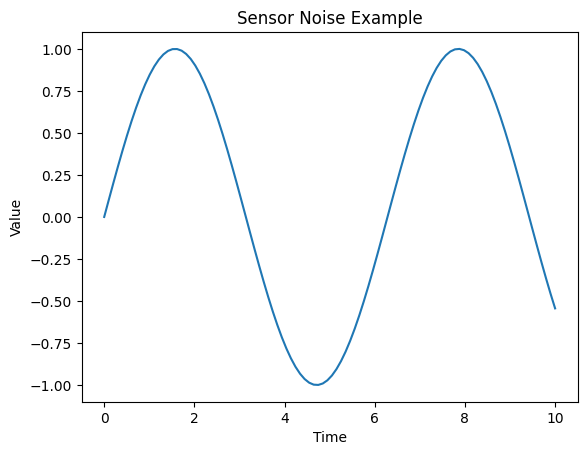

In [4]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

plt.plot(x, y)
plt.title("Sensor Noise Example")
plt.xlabel("Time")
plt.ylabel("Value")
plt.show()

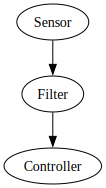

In [5]:
from graphviz import Digraph

dot = Digraph()

dot.node('A', 'Sensor')
dot.node('B', 'Filter')
dot.node('C', 'Controller')

dot.edge('A', 'B')
dot.edge('B', 'C')

dot

<span style="color:red">This is red text</span>

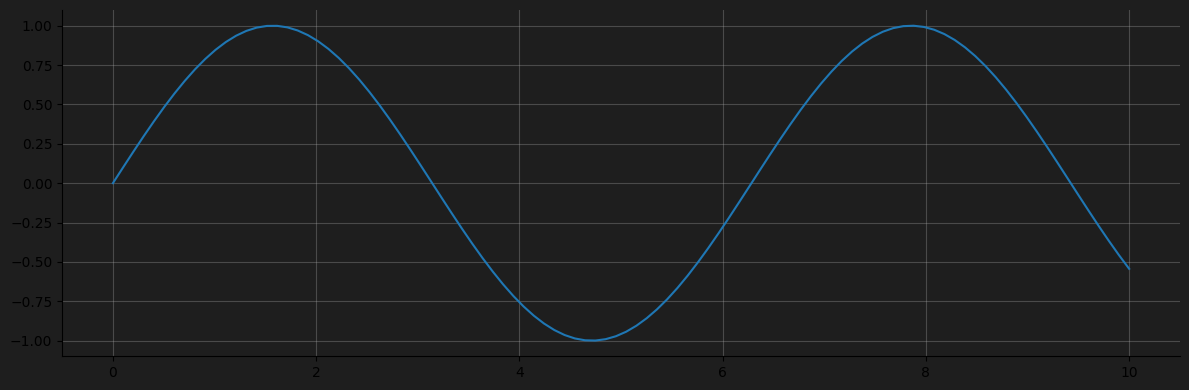

In [10]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(0, 10, 100)
y = np.sin(x)

fig, ax = plt.subplots(figsize=(12, 4))

fig.patch.set_facecolor('#1e1e1e')  # VS Code dark bg
ax.set_facecolor('#1e1e1e')

# Plot
ax.plot(x, y)

# Clean style
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# --- Configuration ---
seconds = 5
fps = 20
total_frames = seconds * fps
interval_ms = 1000 / fps  # 50ms per frame

# 1. Setup Plot
fig, ax = plt.subplots(figsize=(8, 4))
x = np.linspace(0, 4 * np.pi, 1000)
line, = ax.plot(x, np.sin(x), color='#FF5733', lw=3)
ax.set_ylim(-1.2, 1.2)
ax.axis('off') # Keep it clean

# 2. Animation Logic
def update(frame):
    # Progressively draw the wave or shift phase
    line.set_ydata(np.sin(x + frame / 5.0))
    return line,

# 3. Create Animation
# repeat=False ensures it stops after 5 seconds
ani = FuncAnimation(fig, update, frames=total_frames, 
                    interval=interval_ms, blit=True, repeat=False)

plt.close()

# 4. Display with Auto-Play
# 'controls' allows you to see it stopped at the end
# 'autoplay' starts it immediately
# This generates a JS-based player that starts automatically
HTML(ani.to_jshtml())